# Quickstart

In [1]:
from scdesigner.simulators import NegBinCopula
from scdesigner.datasets import pancreas

sim = NegBinCopula(mean_formula="~ bs(pseudotime, df=12)", dispersion_formula="~ bs(pseudotime, df=4)")
sim.fit(pancreas, max_epochs=500)
samples = sim.sample()

Epoch 499/500, Loss: 128011.6090


Estimating copula covariance: 100%|██████████| 3/3 [00:00<00:00, 20.67it/s]


## Gene Summary Stats

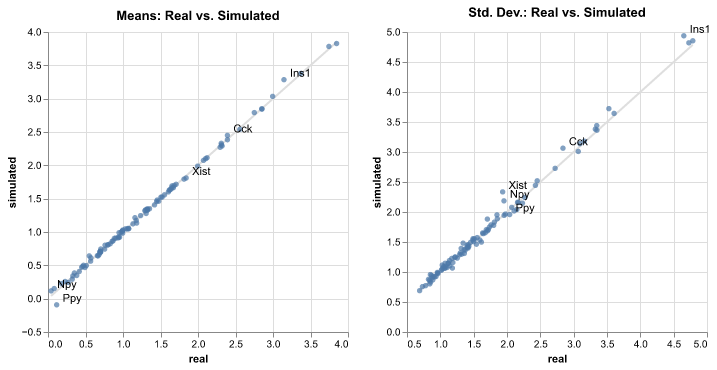

In [2]:
import scdiagnostics as scd
import altair as alt
alt.renderers.enable("png")

scd.compare_moments(pancreas, samples, label_threshold=0.2)

## Gene Details

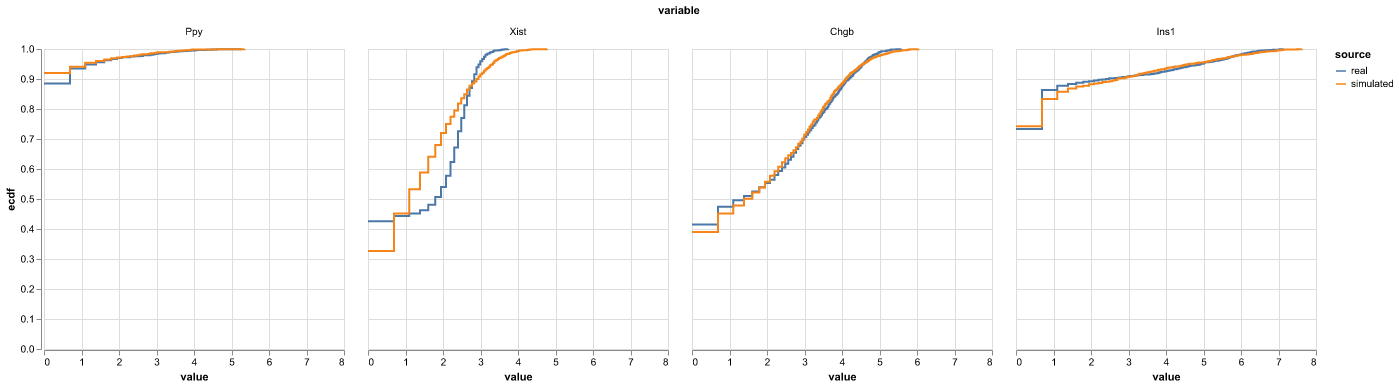

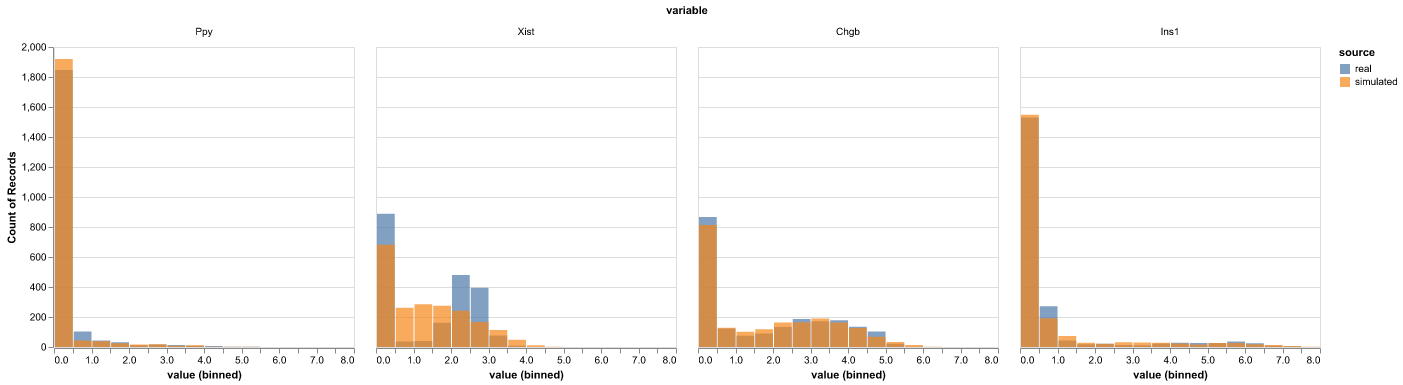

(alt.Chart(...),
          source variable     value
 0          real      Ppy  0.000000
 1          real      Ppy  0.000000
 2          real      Ppy  0.000000
 3          real      Ppy  0.000000
 4          real      Ppy  0.000000
 ...         ...      ...       ...
 8343  simulated     Ins1  0.000000
 8344  simulated     Ins1  1.098612
 8345  simulated     Ins1  0.000000
 8346  simulated     Ins1  0.693147
 8347  simulated     Ins1  0.000000
 
 [16696 rows x 3 columns])

In [3]:
import numpy as np

poor_fit = ["Ppy", "Xist", "Chgb", "Ins1"]
scd.compare_ecdf(pancreas, samples, transform=np.log1p, var_names=poor_fit)
scd.compare_histogram(pancreas, samples, transform=np.log1p, var_names=poor_fit)